#  Tech Assessment: Weather Trend Forecasting

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
# read csv
df = pd.read_csv("./data/GlobalWeatherRepository.csv")
print(df.shape)
df.sample(5)

(130003, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
119084,Belgium,Brussels,50.8333,4.3333,Europe/Brussels,1768893300,2026-01-20 08:15,0.0,32.0,Clear,...,21.750,28.05,2,2,08:34 AM,05:14 PM,09:39 AM,07:08 PM,Waxing Crescent,1
92537,Syria,Damascus,33.5000,36.3000,Asia/Damascus,1756972800,2025-09-04 11:00,24.2,75.6,Sunny,...,28.675,40.70,2,3,06:11 AM,06:56 PM,05:07 PM,02:13 AM,Waxing Gibbous,83
53214,Austria,Vienna,48.2000,16.3667,Europe/Vienna,1739614500,2025-02-15 11:15,1.0,33.8,Partly cloudy,...,14.615,15.54,1,2,07:01 AM,05:17 PM,08:34 PM,08:07 AM,Waning Gibbous,95
7781,Bahrain,Manama,26.2400,50.5800,Asia/Bahrain,1719236700,2024-06-24 16:45,38.4,101.1,Sunny,...,61.800,87.40,3,8,04:47 AM,06:33 PM,09:01 PM,06:48 AM,Waning Gibbous,95
129551,Bolivia,National,-11.1833,-67.0833,America/La_Paz,1773556200,2026-03-15 02:30,22.7,72.8,Mist,...,4.850,4.85,1,1,06:32 AM,06:42 PM,03:27 AM,04:23 PM,Waning Crescent,17


In [ ]:
# display df stats
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,130003.000000,130003.000000,1.300030e+05,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,...,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000,130003.000000
mean,19.203631,21.976354,1.744777e+09,21.404561,70.529999,8.042931,12.947448,168.959509,1014.097521,29.945664,...,18.295989,468.990972,58.452398,15.142142,10.531454,24.463289,48.967420,1.706922,2.625162,49.725629
std,24.420627,65.788604,1.669083e+07,9.688223,17.438649,7.297507,11.741068,103.572696,10.497520,0.309957,...,13.922968,769.933810,30.962557,23.987244,36.312698,37.398961,151.004804,0.946519,2.461476,35.020085
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.870000,-6.836100,1.730365e+09,16.100000,61.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.300000,207.200000,38.000000,1.665000,1.100000,7.150000,10.000000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.744794e+09,24.000000,75.300000,6.900000,11.200000,161.000000,1014.000000,29.930000,...,15.400000,299.700000,55.100000,5.550000,2.405000,14.245000,20.165000,1.000000,2.000000,49.000000
75%,40.400000,50.580000,1.759219e+09,28.000000,82.400000,11.000000,17.600000,255.000000,1018.000000,30.060000,...,24.300000,467.300000,74.000000,17.575000,8.510000,28.050000,41.950000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.773730e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


# Basic Assessment

## Data Cleaning & Preprocessing
* Handle missing values
* outliers
* normalize data

### Missing Values

In [4]:
# Handle missing values
missing_count = df.isnull().sum()

print("Missing values per column")
missing_count[missing_count > 0]

# if missing values, either drop rows with them / replace missing values with mean, median or relevant mode / fill missing values with closest values in column / interpolation technique 

Missing values per column


Series([], dtype: int64)

!!! NO MISSING VALUES

### Outliers
* Outliers that may vary - be careful
    * tmp, humidity, pressure, wind, UV, precipitation 
    * condition text, wind direction, air quality indices
* extreme real event vs real outlier

In [ ]:
# IQR DOES NOT WORK (24,163 outliers)
# Hard limit based on meteorology like max and min celsius known
# Z-score with high threshold 3 or 4?

domain_limits = {
    'temperature_celsius': (-85, 55),  # record low ~ -89.2, high ~ 56.7
    'wind_kph': (0, 408),              # world record wind kph ~408 kph
    'pressure_mb': (870, 1085),        # lows (typhoons) ~870, highs ~1085
    'precip_mm': (0, 1400)             # daily rainfall record ~1825
}

df_original = df.copy()

for col in ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm']:
    # domain clipping 
    lower, upper = domain_limits[col]
    df[col] = df[col].clip(lower=lower, upper=upper)
    
    # z socre clipping 3
    mean = df[col].mean()
    std = df[col].std()
    
    z_upper = mean + 3 * std
    z_lower = mean - 3 * std
    
    # how many are changed
    z_outliers = df[(df[col] < z_lower) | (df[col] > z_upper)].shape[0]
    print(f"{col}: Clipped {z_outliers} statistical outliers (Z > 3).")
    
    # apply clipping
    df[col] = df[col].clip(lower=z_lower, upper=z_upper)

plt.tight_layout()
plt.show()


temperature_celsius: Clipped 0 statistical outliers (Z > 3).
wind_kph: Clipped 0 statistical outliers (Z > 3).
pressure_mb: Clipped 0 statistical outliers (Z > 3).
precip_mm: Clipped 0 statistical outliers (Z > 3).


<Figure size 640x480 with 0 Axes>

In [ ]:
# check stats
stats_check = []
for col in ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm']:
    mean = df[col].mean()
    std = df[col].std()
    stats_check.append({
        'Feature': col,
        'Mean': round(mean, 2),
        'Std Dev': round(std, 2),
        'Lower Bound (Mean - 3σ)': round(mean - 3*std, 2),
        'Upper Bound (Mean + 3σ)': round(mean + 3*std, 2),
        'Max Value': df[col].max()
    })

pd.DataFrame(stats_check)

,Feature,Mean,Std Dev,Lower Bound (Mean - 3σ),Upper Bound (Mean + 3σ),Max Value
0,temperature_celsius,21.52,9.34,-6.51,49.54,45.850
1,wind_kph,12.83,8.02,-11.24,36.90,34.850
2,pressure_mb,1014.08,6.60,994.29,1033.87,1030.000
3,precip_mm,0.02,0.03,-0.07,0.11,0.075


### Normalize Data
* differente scales for data
* XGBoost + LSTM? + Sarimax for seasonality
* XGBoost - NO normalization need (tree based)
* LSTM/SARIMAX - Standard Z-score normalization 

In [14]:
# time sorting
df = df.sort_values('last_updated')

# data split 80 / 20
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# feat to scale
cols_to_scale = ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm', 'humidity']

# fit on train, transform on both
scaler = StandardScaler()
train_df[cols_to_scale] = scaler.fit_transform(train_df[cols_to_scale])
test_df[cols_to_scale] = scaler.transform(test_df[cols_to_scale])

print(f"Split complete. Train set: {train_df.shape[0]} rows | Test set: {test_df.shape[0]} rows")

Split complete. Train set: 104002 rows | Test set: 26001 rows


## Exploratory Data Analysis (EDA)

### Perform basic EDA to uncover the trends, correlations, and patterns.
* feature relationship
* autocorr (ACF) and partial autocorr (PACF)
* spearman heatmap - non linear relation -
* decompose target var into its trend
* Plotting rolling means/standard deviations and performing the Augmented Dickey-Fuller (ADF) test - SARIMAX requires data to be stationary

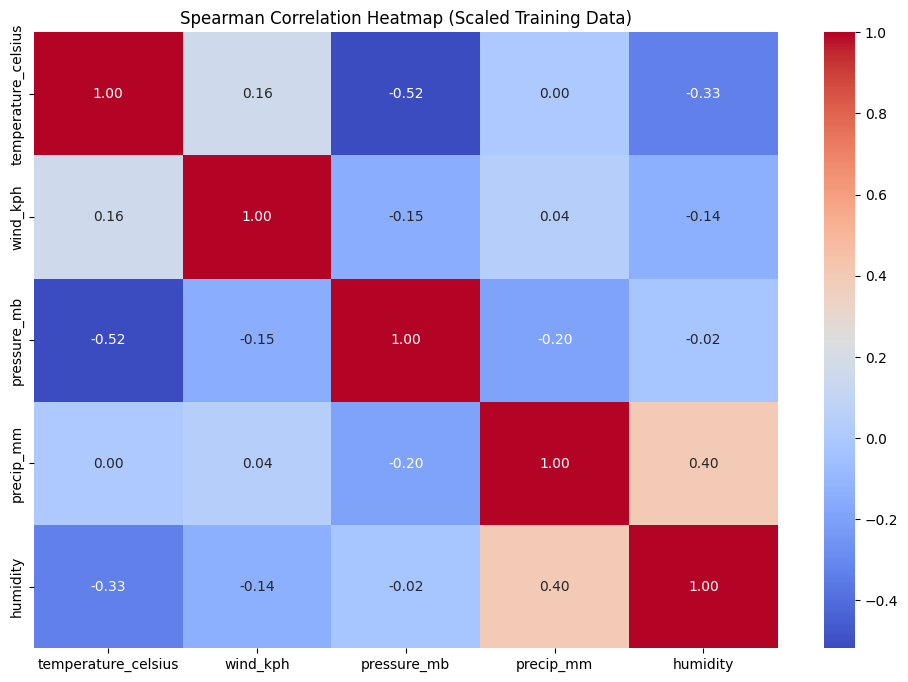

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [17]:

# 1. Heatmap for Feature Relationships
plt.figure(figsize=(12, 8))
# We use Spearman because some weather relationships are monotonic but not linear
correlation_matrix = train_df[cols_to_scale].corr(method='spearman')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap (Scaled Training Data)")
plt.show()

# 2. Seasonal Decomposition (for a specific location or global average)
# Let's look at the global average trend over time
temp_series = train_df.set_index('last_updated')['temperature_celsius'].resample('D').mean()
# Note: Period depends on your data frequency (e.g., 7 for weekly, 30 for monthly)
decomposition = seasonal_decompose(temp_series.dropna(), model='additive', period=7) 

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

### Visualization for temperature and precipitation
* boxplot of temp/precipitaion by continent or region